In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from datetime import datetime
from kneed import KneeLocator
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

Let's load the data and show the data types to verify that we are working with numerical data

In [51]:
# Load the dataset
df = pd.read_csv('../timeseries_datasets/tracks.csv')

In [52]:
artist_name_map = {
    "ART25707984": "fabri fibra",
    "ART07024718": "fedez"
}

We can see that no null value is present in this dataset

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        440 non-null    object 
 1   id_artist                 440 non-null    object 
 2   num_samples               440 non-null    int64  
 3   sr                        440 non-null    int64  
 4   duration_ms               440 non-null    float64
 5   bpm                       440 non-null    float64
 6   centroid_mean             440 non-null    float64
 7   centroid_std              440 non-null    float64
 8   rolloff_mean              440 non-null    float64
 9   rolloff_std               440 non-null    float64
 10  flux_mean                 440 non-null    float64
 11  flux_std                  440 non-null    float64
 12  rms_mean                  440 non-null    float64
 13  rms_std                   440 non-null    float64
 14  zcr_mean  

In [54]:
df.dtypes

id                           object
id_artist                    object
num_samples                   int64
sr                            int64
duration_ms                 float64
bpm                         float64
centroid_mean               float64
centroid_std                float64
rolloff_mean                float64
rolloff_std                 float64
flux_mean                   float64
flux_std                    float64
rms_mean                    float64
rms_std                     float64
zcr_mean                    float64
zcr_std                     float64
flatness_mean               float64
flatness_std                float64
spectral_complexity_mean    float64
spectral_complexity_std     float64
pitch_mean                  float64
pitch_std                   float64
loudness_mean               float64
loudness_std                float64
silence_start_sec           float64
silence_end_sec             float64
silence_middle_total_sec    float64
silence_middle_count        

In [55]:
df.head()

,id,id_artist,num_samples,sr,duration_ms,bpm,centroid_mean,centroid_std,rolloff_mean,rolloff_std,...,pitch_mean,pitch_std,loudness_mean,loudness_std,silence_start_sec,silence_end_sec,silence_middle_total_sec,silence_middle_count,silence_middle_mean_sec,is_silent
0,TR597348,ART25707984,1323000,22050,60000.0,103.359375,1829.634696,513.633085,3632.365536,1251.702789,...,166.056295,82.768208,-6.099958,3.400751,0.00,0.0,0.16,6,0.03,False
1,TR745549,ART07024718,1323000,22050,60000.0,184.570312,3104.869592,865.268063,6785.379803,1396.211133,...,94.284803,53.955332,-4.782125,2.406209,0.00,0.0,0.00,0,0.00,False
2,TR324941,ART25707984,1323000,22050,60000.0,161.499023,2681.050056,830.110964,5994.026255,1533.435198,...,123.373624,88.474871,-6.170307,3.563172,0.02,0.0,0.35,3,0.12,False
3,TR496653,ART07024718,1323000,22050,60000.0,92.285156,2433.401636,914.693105,5803.939904,1797.581388,...,91.459176,76.265113,-7.353655,3.444985,0.00,0.0,0.60,2,0.30,False
4,TR910855,ART25707984,1323000,22050,60000.0,95.703125,2960.550410,864.289578,6550.868721,1524.216276,...,135.255304,89.036718,-5.228243,3.021941,0.00,0.0,0.02,1,0.02,False


## Data exploration
In this step we explore the dataset prepared for clustering and check for data distribution

In [56]:
df.drop(["id", "num_samples", "sr", "centroid_std", "rolloff_std", "flux_std", "rms_std", "zcr_std", "flatness_std", "spectral_complexity_std", "pitch_std", "loudness_std", "silence_middle_total_sec", "is_silent"], axis=1, inplace=True)

In [57]:
df.head()

,id_artist,duration_ms,bpm,centroid_mean,rolloff_mean,flux_mean,rms_mean,zcr_mean,flatness_mean,spectral_complexity_mean,pitch_mean,loudness_mean,silence_start_sec,silence_end_sec,silence_middle_count,silence_middle_mean_sec
0,ART25707984,60000.0,103.359375,1829.634696,3632.365536,1.913256,0.256541,0.075866,0.006975,2133.886542,166.056295,-6.099958,0.00,0.0,6,0.03
1,ART07024718,60000.0,184.570312,3104.869592,6785.379803,1.476795,0.240214,0.142538,0.059145,2936.665151,94.284803,-4.782125,0.00,0.0,0,0.00
2,ART25707984,60000.0,161.499023,2681.050056,5994.026255,1.723460,0.141660,0.112018,0.033351,2762.948751,123.373624,-6.170307,0.02,0.0,3,0.12
3,ART07024718,60000.0,92.285156,2433.401636,5803.939904,1.509449,0.292506,0.076226,0.017405,2856.940934,91.459176,-7.353655,0.00,0.0,2,0.30
4,ART25707984,60000.0,95.703125,2960.550410,6550.868721,1.808202,0.271711,0.117349,0.036084,2912.308380,135.255304,-5.228243,0.00,0.0,1,0.02


Now we plot the data distribution and check for each column what are the values

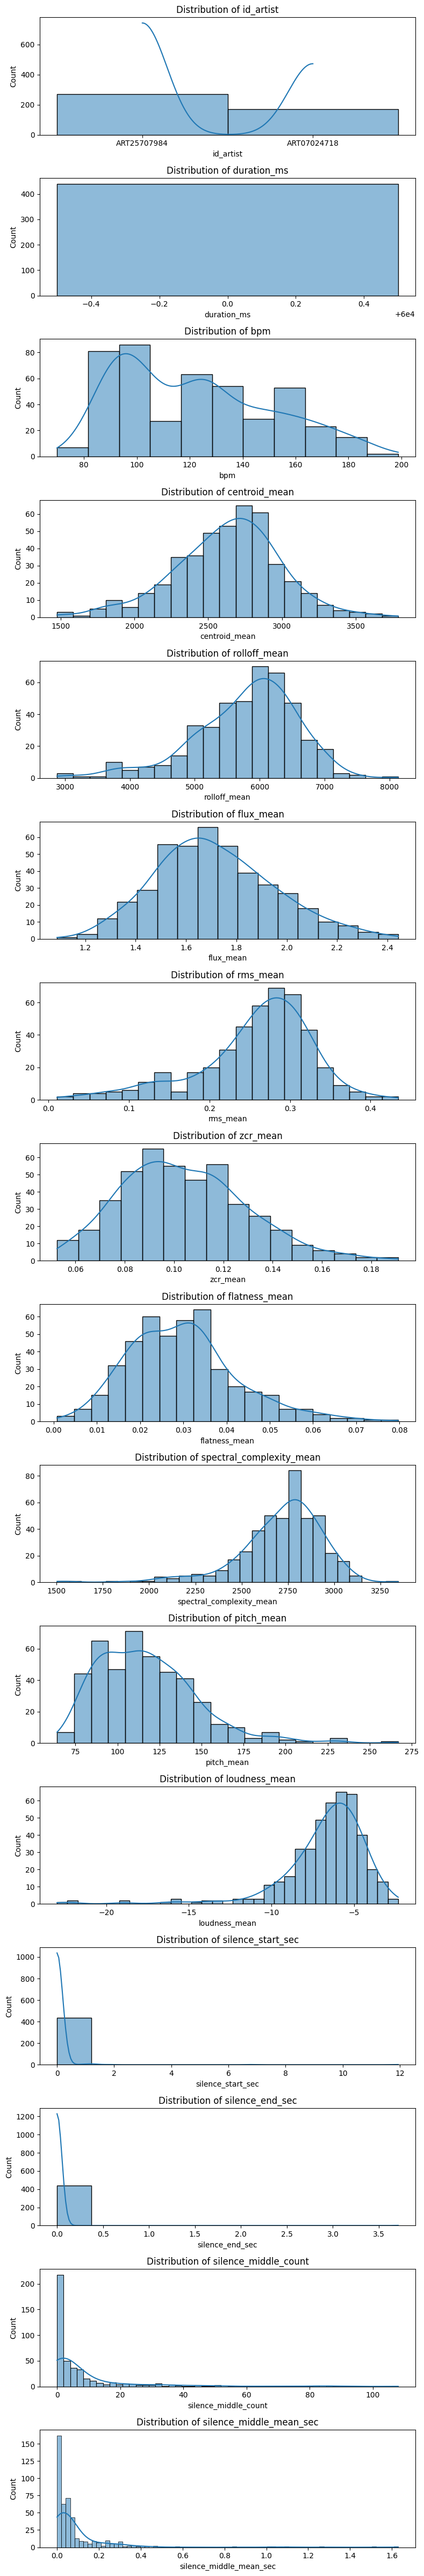

In [58]:
musical_cols = df.columns

fig, axs = plt.subplots(len(musical_cols), 1, figsize=(8, 3*len(musical_cols)))
for i,c in enumerate(musical_cols):
    ax = axs[i] if len(musical_cols)>1 else axs
    sns.histplot(df[c].dropna(), kde=True, ax=ax)
    ax.set_title(f'Distribution of {c}')
plt.tight_layout()

plt.show()

## Normalizing data
In this step we normalize the dataset using the standard scaler so that all values are brought in the same range values.
We also exclude the artist id column as it is not used in clustering

In [59]:
clustering_df = df.iloc[:,1:]
clustering_df.head()

,duration_ms,bpm,centroid_mean,rolloff_mean,flux_mean,rms_mean,zcr_mean,flatness_mean,spectral_complexity_mean,pitch_mean,loudness_mean,silence_start_sec,silence_end_sec,silence_middle_count,silence_middle_mean_sec
0,60000.0,103.359375,1829.634696,3632.365536,1.913256,0.256541,0.075866,0.006975,2133.886542,166.056295,-6.099958,0.00,0.0,6,0.03
1,60000.0,184.570312,3104.869592,6785.379803,1.476795,0.240214,0.142538,0.059145,2936.665151,94.284803,-4.782125,0.00,0.0,0,0.00
2,60000.0,161.499023,2681.050056,5994.026255,1.723460,0.141660,0.112018,0.033351,2762.948751,123.373624,-6.170307,0.02,0.0,3,0.12
3,60000.0,92.285156,2433.401636,5803.939904,1.509449,0.292506,0.076226,0.017405,2856.940934,91.459176,-7.353655,0.00,0.0,2,0.30
4,60000.0,95.703125,2960.550410,6550.868721,1.808202,0.271711,0.117349,0.036084,2912.308380,135.255304,-5.228243,0.00,0.0,1,0.02


In [60]:
scaler = StandardScaler()
# apply scaling
X_scaled = scaler.fit_transform(clustering_df.values)
X_scaled

array([[ 0.        , -0.64637621, -2.21652713, ..., -0.05501943,
        -0.15209075, -0.33487165],
       [ 0.        ,  2.18535288,  1.3146874 , ..., -0.05501943,
        -0.5457374 , -0.50862581],
       [ 0.        ,  1.38088439,  0.14110149, ..., -0.05501943,
        -0.34891408,  0.18639083],
       ...,
       [ 0.        ,  0.2546285 ,  1.16157791, ..., -0.05501943,
        -0.15209075,  0.82348941],
       [ 0.        ,  0.491735  ,  0.20159722, ..., -0.05501943,
        -0.5457374 , -0.50862581],
       [ 0.        , -0.1549191 , -0.42206979, ..., -0.05501943,
        -0.41452185,  8.93201685]], shape=(440, 15))

## K-means execution
Now we run k means testing k values from 2 to 10, we store SSE and silhouette scores for each k tested

In [61]:
k_range = range(2, 10)
sse_values = []
silhouette_scores = []

for k in k_range:
    print(f"Fitting k: {k}", end=" ")

    # run k means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    # get SSE
    sse = kmeans.inertia_
    sse_values.append(sse)

    # compute silhouette score
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

    print(f"SSE: {sse:.2f} - Silhouette Score: {silhouette_avg:.4f}")


Fitting k: 2 SSE: 5009.46 - Silhouette Score: 0.2361
Fitting k: 3 SSE: 4357.56 - Silhouette Score: 0.1973
Fitting k: 4 SSE: 3917.94 - Silhouette Score: 0.2045
Fitting k: 5 SSE: 3556.19 - Silhouette Score: 0.1468
Fitting k: 6 SSE: 3134.20 - Silhouette Score: 0.1530
Fitting k: 7 SSE: 2892.38 - Silhouette Score: 0.1662
Fitting k: 8 SSE: 2643.74 - Silhouette Score: 0.1757
Fitting k: 9 SSE: 2478.56 - Silhouette Score: 0.1448


In [62]:
kneedle = KneeLocator(k_range, sse_values, curve='convex', direction='decreasing')
best_k = kneedle.elbow

print(f"Best K = {best_k}. Elbow method on SSE")

Best K = 6. Elbow method on SSE


## Visualization
Finally we can plot how silhouette scores are distributed for each k value and  

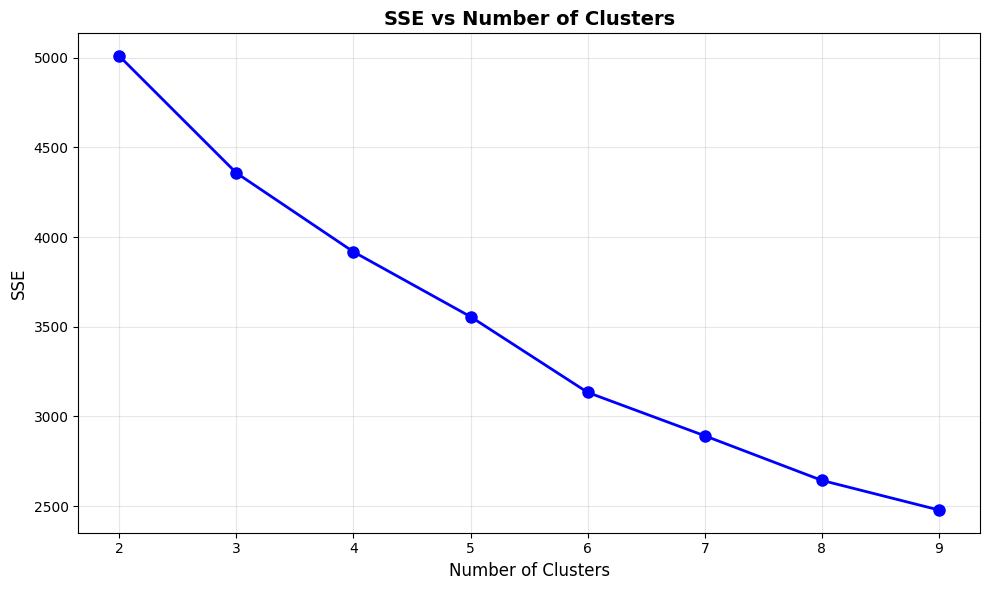

In [63]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, sse_values, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('SSE', fontsize=12)
plt.title('SSE vs Number of Clusters', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

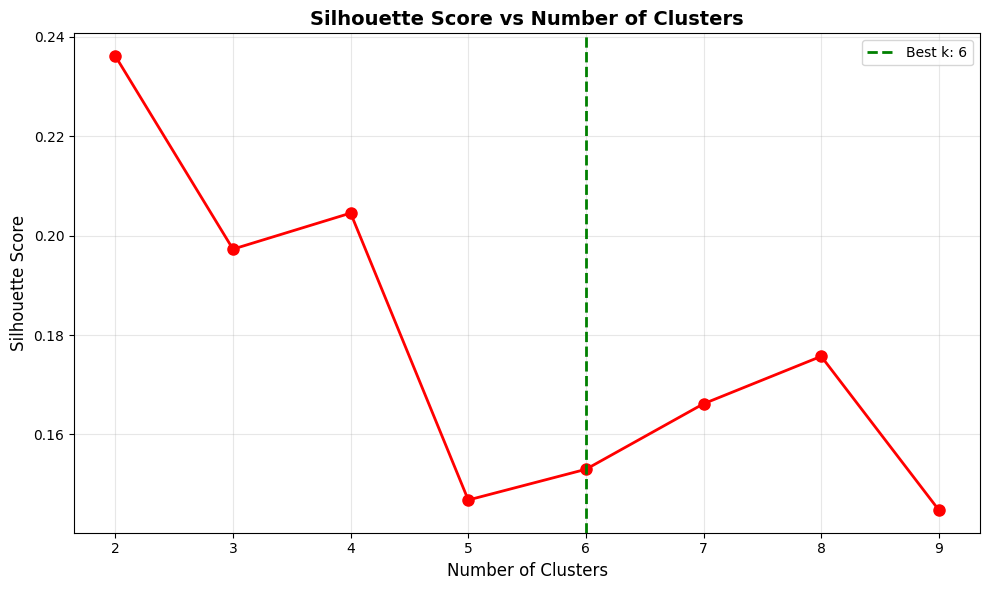

In [64]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='g', linestyle='--', linewidth=2, label=f'Best k: {best_k}')
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs Number of Clusters', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [65]:
def k_means_run_analysis(num_clusters, num_pca_components):
    print(f"=========== Testing K-means with K = {num_clusters} ===========")
    kmeans_best = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    best_k_labels = kmeans_best.fit_predict(X_scaled)
    
    # plot pca componetns
    pca = PCA(n_components=num_pca_components)
    X_pca = pca.fit_transform(X_scaled)
    
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_k_labels,
                                cmap='viridis', edgecolors='k')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
    plt.title(f'K-means with k: {num_clusters}',
                        fontsize=14, fontweight='bold')
    
    # plot cluster sizes
    # cluster sizes
    plt.figure(figsize=(10, 6))
    cluster_counts = pd.Series(best_k_labels).value_counts().sort_index()
    plt.bar(cluster_counts.index, cluster_counts.values, color='steelblue', edgecolor='black')
    plt.xlabel('Cluster Number', fontsize=12)
    plt.ylabel('Cluster Elements', fontsize=12)
    plt.title(f'Cluster Sizes k: {num_clusters}', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='y')
    
    # box plot of features
    n_features = len(clustering_df.columns)
    n_cols = 4
    n_rows = (n_features + n_cols - 1) // n_cols

    fig3, axes3 = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
    axes3 = axes3.flatten()
    
    clustering_df['cluster'] = best_k_labels
    # skip cluster column which is generated by k means
    feature_columns = [col for col in clustering_df.columns if col != 'cluster']

    for idx, column in enumerate(feature_columns):
        ax = axes3[idx]

        # Prepare data for boxplot
        data_by_cluster = [clustering_df[clustering_df['cluster'] == i][column].values
                        for i in range(num_clusters)]

        bp = ax.boxplot(data_by_cluster, labels=[f'C{i}' for i in range(num_clusters)],
                        patch_artist=True, showmeans=True)

        # Color the boxplots
        colors = plt.cm.viridis(np.linspace(0, 1, num_clusters))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.set_title(column, fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        
    plt.show()

We can see that the optimal value found with the elbow method is k = 3 clusters.
From Silhouette score we can see that the optimal value would be k = 2 with k = 5 and k = 7 following.
Let's analyze all values and see the results

=========== Testing K-means with K = 2 ===========


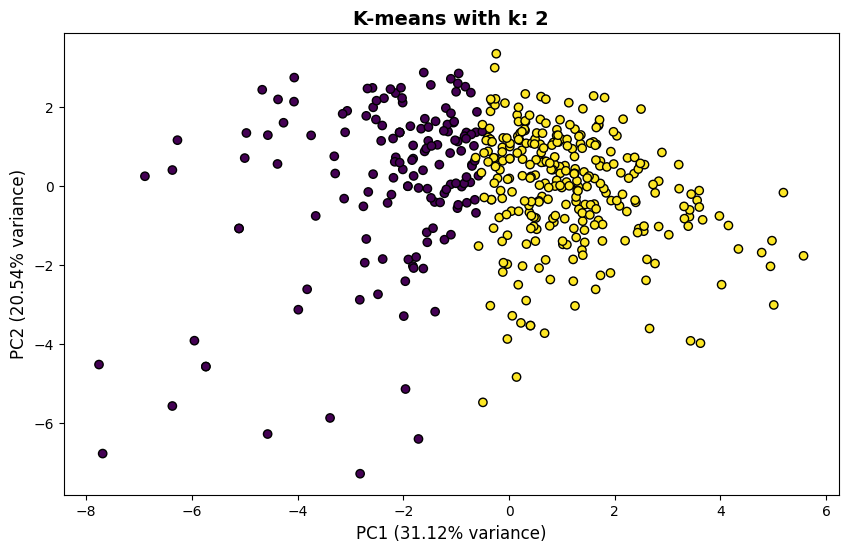

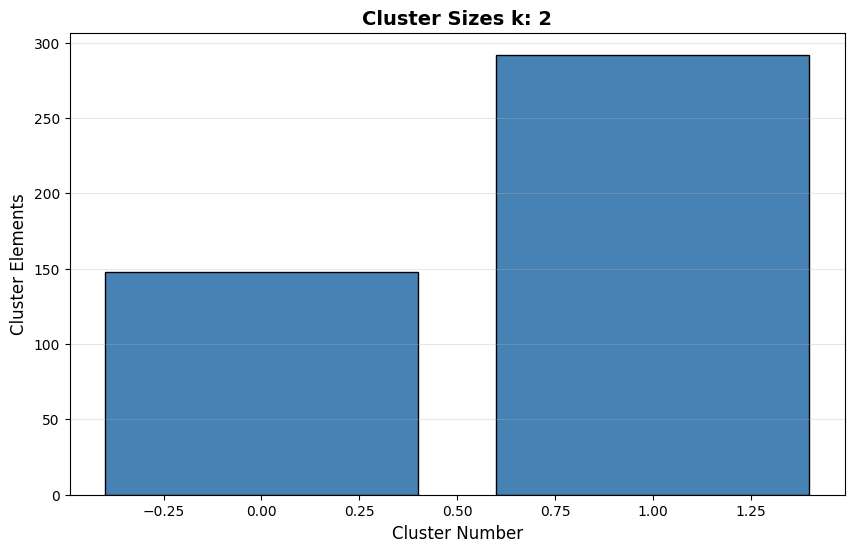

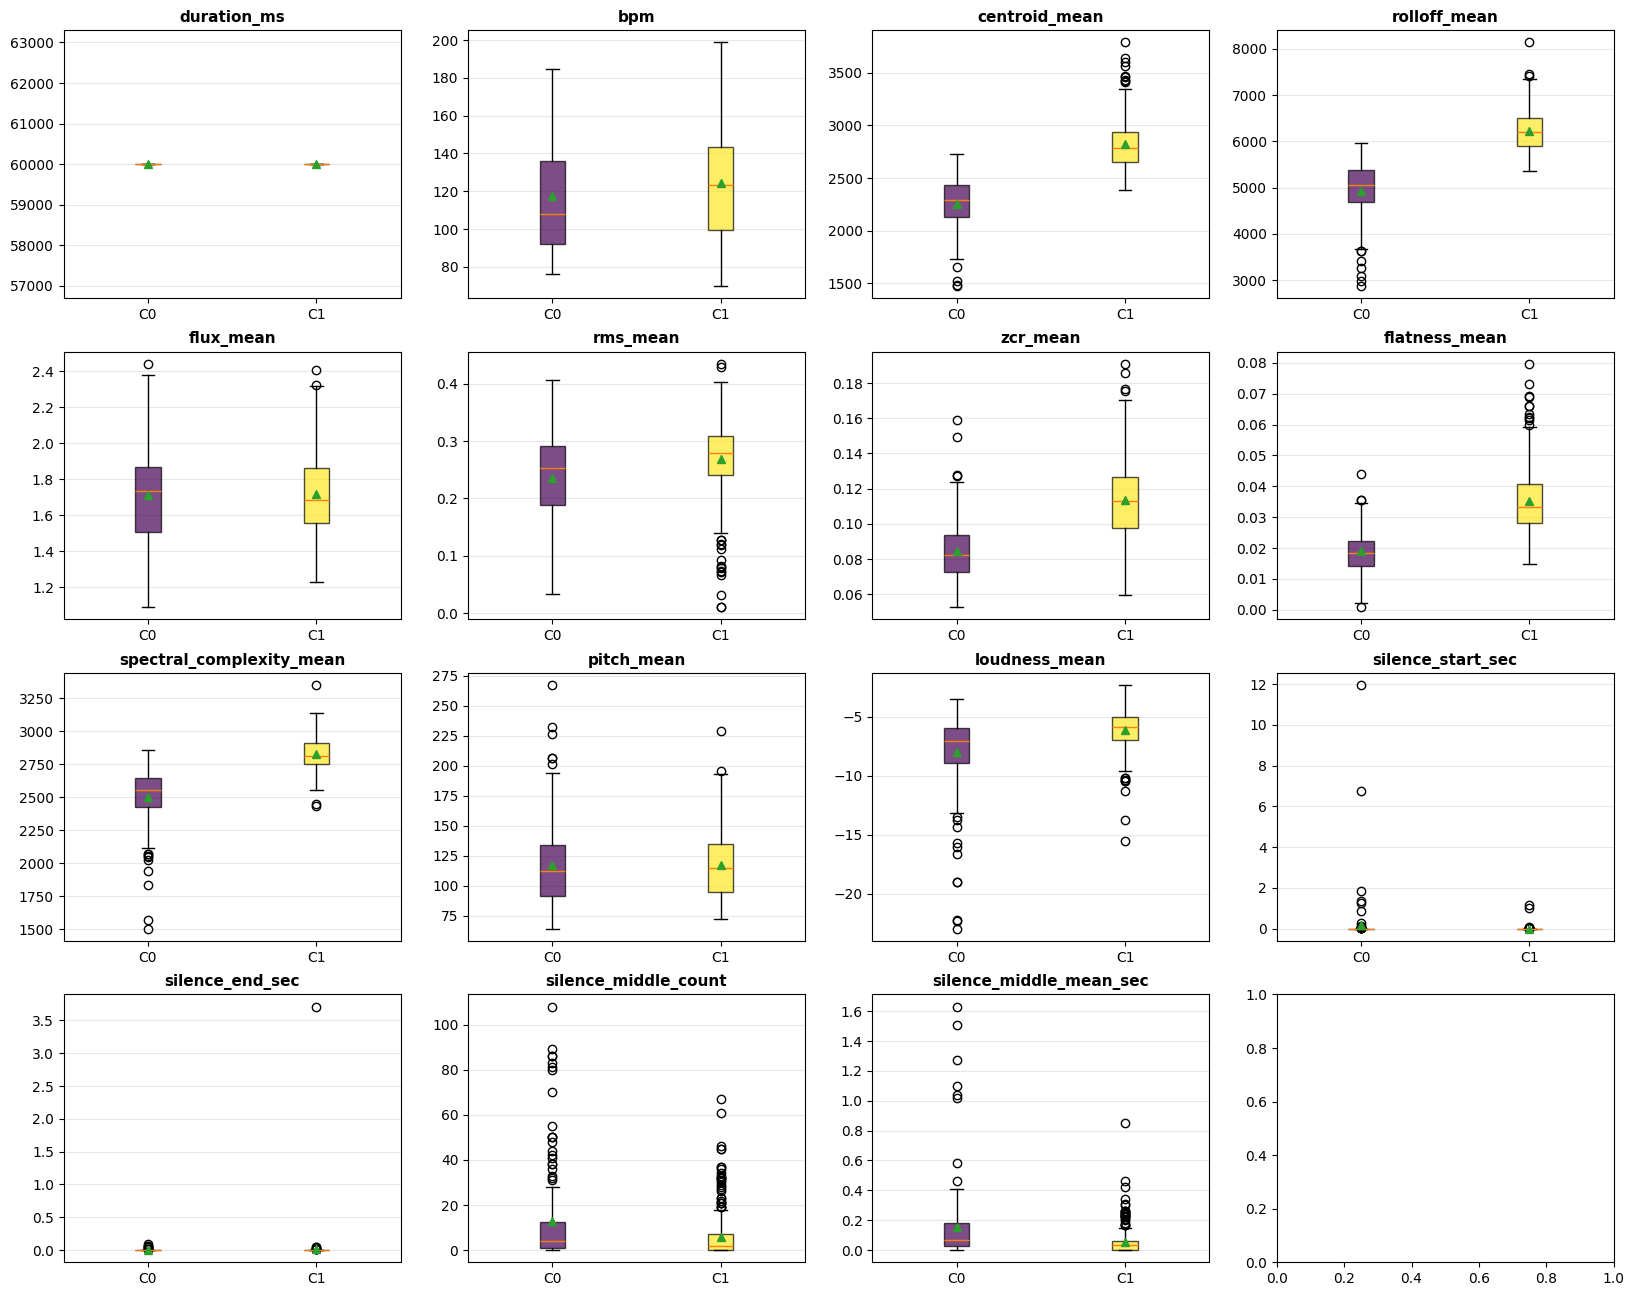

=========== Testing K-means with K = 4 ===========


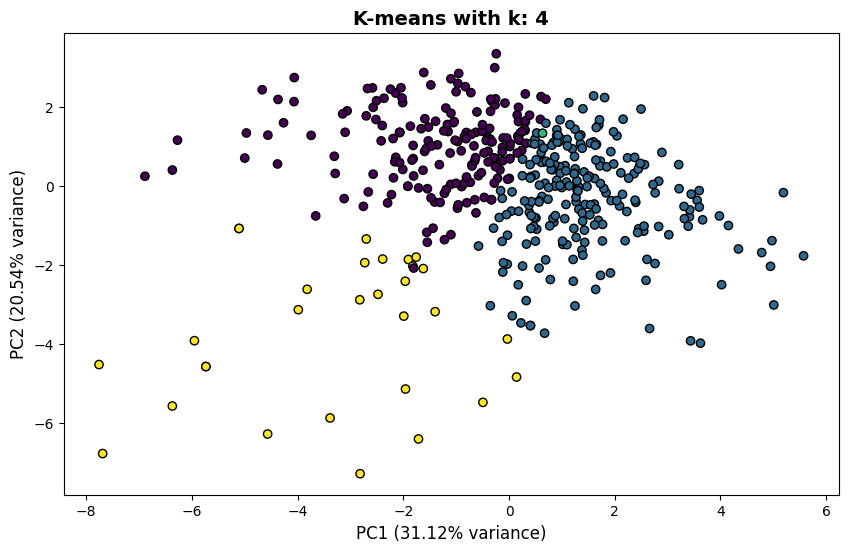

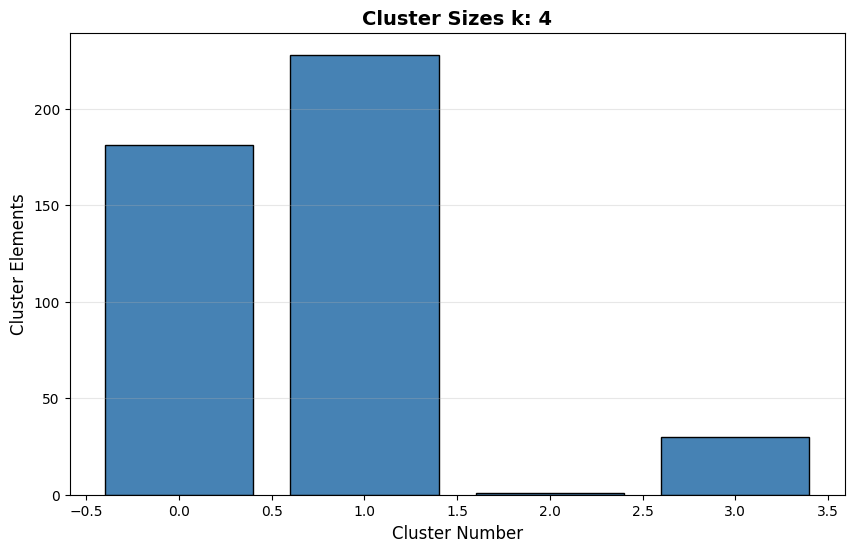

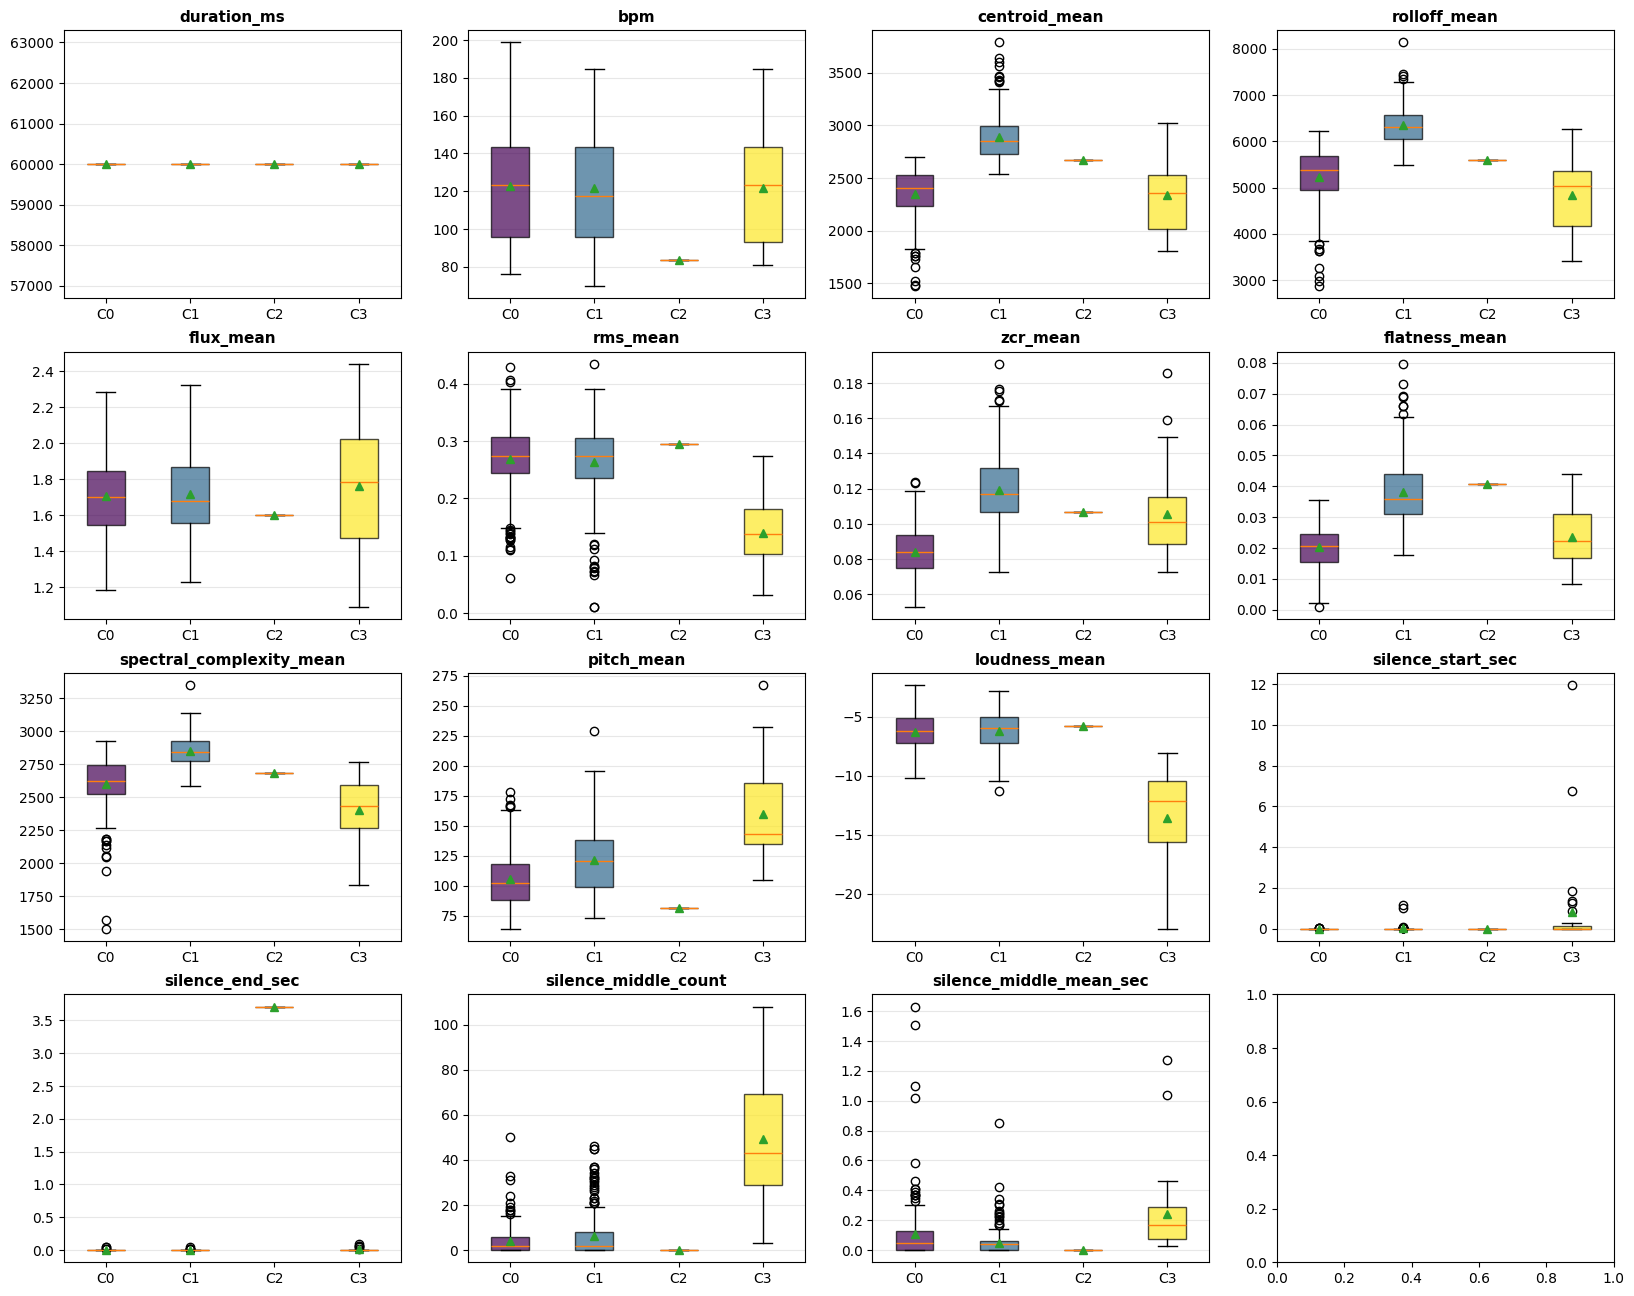

=========== Testing K-means with K = 5 ===========


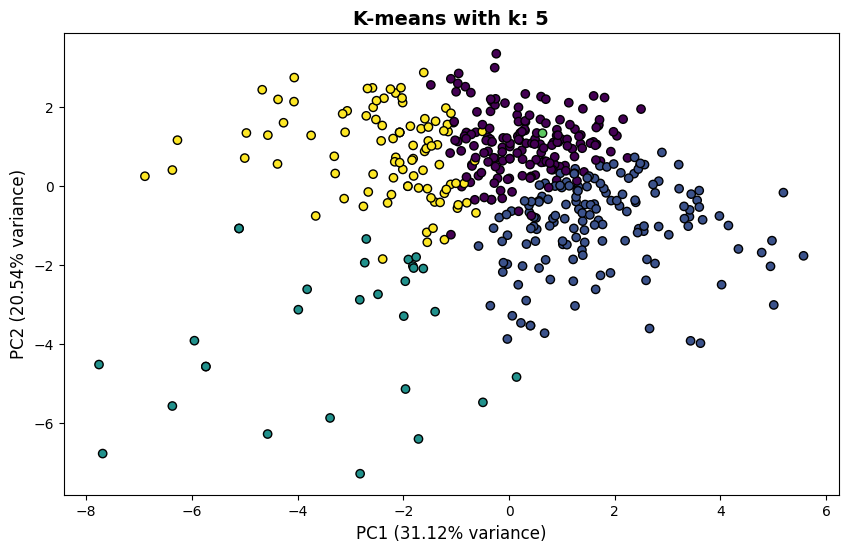

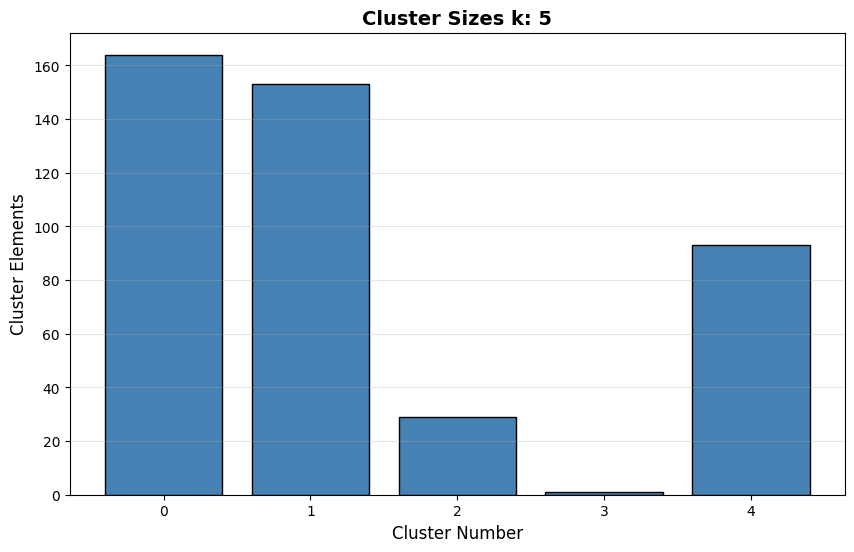

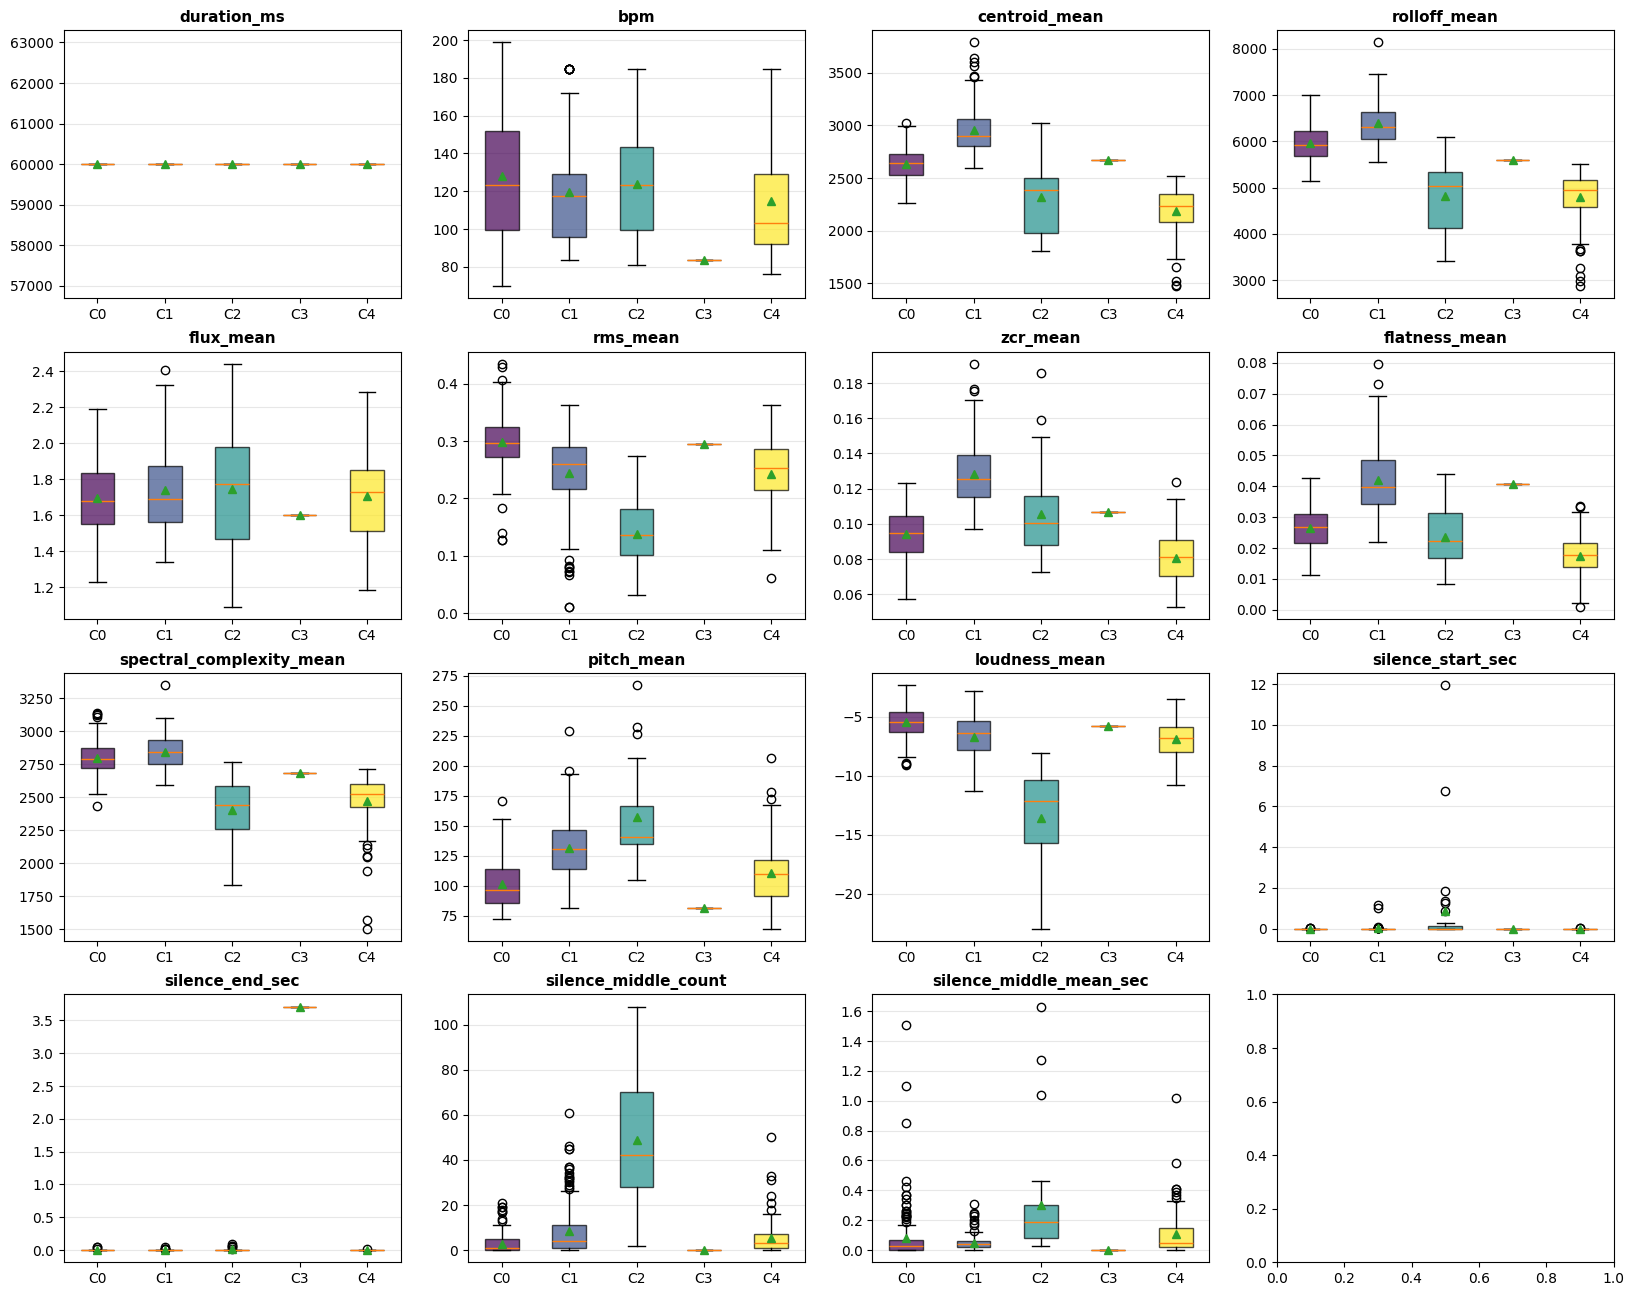

In [66]:
k_to_test = [2,4,5]

for k in k_to_test:
    k_means_run_analysis(num_clusters=k, num_pca_components=2)

# Cluster analysis

In [67]:
for num_clusters in k_to_test:
    kmeans_best = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    best_k_labels = kmeans_best.fit_predict(X_scaled)

    df['cluster'] = best_k_labels
    df['artist'] = df["id_artist"].apply(lambda x: artist_name_map.get(x))

    cluster_artist_distribution = (
        df
        .assign(cluster=best_k_labels)
        .groupby(['cluster', 'artist'])
        .size()
        .unstack(fill_value=0)
    )

    # Add totals per cluster
    cluster_artist_distribution['total'] = cluster_artist_distribution.sum(axis=1)
    cluster_artist_distribution['fedez_perc'] = (cluster_artist_distribution['fedez'] / cluster_artist_distribution['total']) * 100
    cluster_artist_distribution['fabri_perc'] = (cluster_artist_distribution['fabri fibra'] / cluster_artist_distribution['total']) * 100
    print(f"K = {num_clusters}\n")
    print(cluster_artist_distribution)
    print("-----------------------------")
    print("\n")

K = 2

artist   fabri fibra  fedez  total  fedez_perc  fabri_perc
cluster                                                   
0                 81     67    148   45.270270   54.729730
1                188    104    292   35.616438   64.383562
-----------------------------


K = 4

artist   fabri fibra  fedez  total  fedez_perc  fabri_perc
cluster                                                   
0                 90     91    181   50.276243   49.723757
1                157     71    228   31.140351   68.859649
2                  0      1      1  100.000000    0.000000
3                 22      8     30   26.666667   73.333333
-----------------------------


K = 5

artist   fabri fibra  fedez  total  fedez_perc  fabri_perc
cluster                                                   
0                 90     74    164   45.121951   54.878049
1                113     40    153   26.143791   73.856209
2                 21      8     29   27.586207   72.413793
3                  0      1   